# 3.4 微积分：参数动一点，损失会怎样

> 3.0 基础课程：先直觉，再符号，再数字代入，再用代码和图形核对。

## Goal

从斜率和有限差分进入导数、偏导、梯度、方向导数、链式法则、计算图、反向传播与激活饱和。

## Setup 与数据边界

本课不加载用户行为数据。代码中的小数组都是带标签的 **数学教学对象**，只用于验证公式，绝不冒充交互、曝光、标签或行为序列。

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
TEACHING_OBJECTS_ONLY = True
print({"project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "kind": "curriculum", "teaching_objects_only": True})

from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中的 Noto CJK
# （镜像已安装 fonts-noto-cjk），其次是宿主机常见中文字体；从字体根源解决，
# 而不是用 warnings.filterwarnings 掩盖 missing glyph 警告。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'PingFang SC', 'Hiragino Sans GB',
                  'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('图表字体:', cjk_font or '未找到中文字体（请安装 fonts-noto-cjk）')

{'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'kind': 'curriculum', 'teaching_objects_only': True}
图表字体: Noto Sans CJK JP


## 学习路径

先把模型看成输入到输出的函数；用相邻两点估计坡度；再把一个变量推广到许多参数；最后沿计算图反向应用链式法则。

## 符号表

| 符号 | 含义 |
|---|---|
| $f(x)$ | 输入 $x$ 经过函数后的输出 |
| $f'(x)$ 或 $df/dx$ | $x$ 动一点时输出的瞬时变化率 |
| $\partial L/\partial w$ | 其他变量暂时固定时，损失对 $w$ 的偏导 |
| $\nabla L$ | 把所有参数偏导排成的梯度向量 |
| $\eta$ | 学习率，即每步走多远 |

> 下文数值全部是数学教学对象，不代表真实交互。

<a id="functions"></a>
## 1. 函数与复合

函数像一台规则明确的机器。模型常是复合函数：$x\xrightarrow{g}z\xrightarrow{h}\hat y\xrightarrow{\ell}L$。例如 $z=wx+b$，$hat y=\sigma(z)$，再由标签和预测计算损失。

### 数字代入 1：复合三步

令 $x=2,w=3,b=-1$，则 $z=3\times2-1=5$；若 $h(z)=z^2$，则 $h(5)=25$；若目标为 20，平方误差 $(25-20)^2=25$。每个中间量都能单独核对。

<a id="derivative-gradient"></a>
## 2. 导数、偏导、梯度与方向

有限差分用 $[f(x+h)-f(x)]/h$ 估计斜率。对 $f(x)=x^2$、$x=3$、$h=0.01$，得到 $(3.01^2-3^2)/0.01=6.01$，接近导数 $2x=6$。

多个参数时分别求偏导，再组成梯度。方向导数是梯度与单位方向 $v$ 的点积 $\nabla L\cdot v$；负梯度是局部下降最快方向。

### 数字代入 2：二维梯度

$L(w,b)=(w-2)^2+(b+1)^2$，在 $(w,b)=(4,2)$ 处，梯度为 $[2(4-2),2(2+1)]=[4,6]$。沿 $-[4,6]$ 走一小步会降低损失。

1.0 7.0
0.1 6.100000000000012
0.01 6.009999999999849
0.001 6.000999999999479


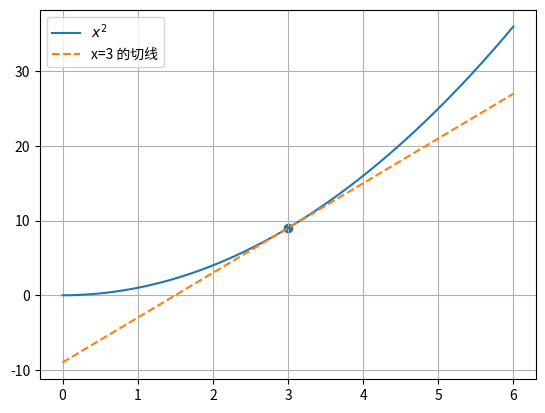

In [2]:
# Demo 1：有限差分靠近解析导数，并画出切线。
f = lambda x: x**2
x0 = 3.0
for h in [1., .1, .01, .001]:
    print(h, (f(x0+h)-f(x0))/h)
xs = np.linspace(0,6,200)
plt.plot(xs, f(xs), label="$x^2$")
plt.plot(xs, f(x0)+2*x0*(xs-x0), "--", label="x=3 的切线")
plt.scatter([x0],[f(x0)]); plt.legend(); plt.grid(); plt.show()

<a id="chain-rule"></a>
## 3. 链式法则、计算图与反向传播

若 $y=h(z)$、$z=g(x)$，那么 $dy/dx=(dy/dz)(dz/dx)$。反向传播不是另一套数学，而是把这条规则从损失端沿计算图逐边相乘，并把分叉路径的贡献相加。

### 数字代入 3：一条链反向算

$z=2x+1$，$y=z^2$。在 $x=3$ 时 $z=7$。$dy/dz=2z=14$，$dz/dx=2$，所以 $dy/dx=14\times2=28$。直接展开 $y=(2x+1)^2$ 求导，也得 $2(2x+1)\times2=28$。

激活函数会影响梯度。Sigmoid 在 $z=0$ 的导数为 $0.25$，到 $z=8$ 时接近 0，叫“饱和”；许多层连续乘很小的导数，会造成梯度消失。ReLU 正区间导数为 1，但负区间为 0，也要留意神经元长期不激活。

### 数字代入 4：饱和

$\sigma(0)=0.5$，导数 $0.5(1-0.5)=0.25$；$\sigma(8)\approx0.9997$，导数约 $0.00034$，一层就把传回的梯度缩小约 735 倍。

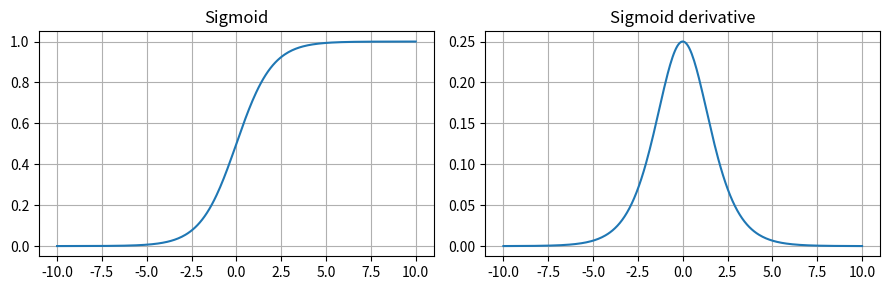

{'numeric': 28.000000000361066, 'analytic': 28.0}


In [3]:
# Demo 2：计算图的数值梯度与解析梯度；同时观察 Sigmoid 饱和。
def composed(x):
    z = 2*x + 1
    return z**2
x = 3.; eps = 1e-5
numeric = (composed(x+eps)-composed(x-eps))/(2*eps)
analytic = 2*(2*x+1)*2
z = np.linspace(-10,10,300); sig = 1/(1+np.exp(-z)); derivative = sig*(1-sig)
fig, ax = plt.subplots(1,2,figsize=(9,3))
ax[0].plot(z,sig); ax[0].set_title("Sigmoid")
ax[1].plot(z,derivative); ax[1].set_title("Sigmoid derivative")
for a in ax: a.grid()
plt.tight_layout(); plt.show()
print({"numeric": numeric, "analytic": analytic})

## 常见误区

- 导数是“函数值”：导数是局部变化率，可能为负。
- 偏导时所有变量一起变：求某一偏导时暂时固定其他变量。
- 梯度就是更新方向：梯度指向上升最快，梯度下降走负梯度。
- 反向传播会自动保证模型正确：它只忠实求当前计算图的导数。

## 算法回链

- [BiasMF：评分误差对隐向量的梯度](/notebooks/4_3_matrix_factorization)
- [DeepFM：共享 embedding 的两条梯度路径](/notebooks/6_2_deepfm)
- [DIEN：序列网络与辅助损失反传](/notebooks/6_4_dien)
- [HSTU：深层序列模型的梯度稳定性](/notebooks/8_3_dlrm_hstu_practice)

## Checks

1. $f(x)=3x+2$ 的导数为何处处为 3？
2. 梯度 $[4,6]$ 时，下降应取哪个方向？
3. 链式法则为什么是相乘而不是相加？

In [4]:
assert abs(numeric-analytic) < 1e-4
gradient = np.array([4.,6.]); before = (4-2)**2 + (2+1)**2
after_point = np.array([4.,2.]) - .1*gradient
after = (after_point[0]-2)**2 + (after_point[1]+1)**2
assert after < before
print("PASS：有限差分、链式法则与负梯度下降检查通过。")

PASS：有限差分、链式法则与负梯度下降检查通过。


## Next Steps

下一课解释标签为何能写成概率和似然；之后再把梯度与学习率、正则化组合成完整优化过程。